---
## Scetion 0: Initial setup

**Imports**

In [1]:
# Imports
import sys
from pathlib import Path

# This notebook only orchestrates. Every function and class it calls lives in the
# `macrocircuits` package under src/ -- read or edit it there.
SRC = str(Path.cwd().parent / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import matplotlib.pyplot as plt
from IPython.display import display

# Importing macrocircuits also registers this repo's swimmer tasks -- `swim`,
# `swim_12_links`, `swim_to_ball`, `foraging` and `evasion` -- with the dm_control
# swimmer suite, which is what lets suite.load() find them below.
# test_dm_control just steps an environment with random actions and renders it, which
# is all the sanity check below needs.
from dm_control import suite
from macrocircuits import ensure_tonic, test_dm_control

# Clone neuromatch/tonic next to this notebook (once) and put it on the import path.
# It has to run before the tonic-backed imports below (training, models); see
# src/macrocircuits/tonic_setup.py for why tonic isn't a pip install.
ensure_tonic()

# The Swim task rewards swimming forward at _SWIM_SPEED and hides the target the
# stock dm_control swimmer chases. resolve_runs/run_config/run_path turn the runs
# declared in Section 1 into the code strings train() needs and the paths it writes.
# is_trained lets the training cell skip a run whose exact parameters were already
# trained, instead of overwriting its checkpoints.
from macrocircuits.training import (  # See src/macrocircuits/training.py.
    is_trained,
    play_model,
    resolve_runs,
    run_config,
    run_path,
    train,
)
# The Evolution Strategies path -- method='es' below. It is a separate trainer, not a
# tonic agent, so it has its own config/train/play trio. See src/macrocircuits/es.py.
# is_es_trained is its counterpart to is_trained.
from macrocircuits.es import (
    es_config,
    is_es_trained,
    play_es_model,
    run_es,
)
from macrocircuits.plotting import (  # See src/macrocircuits/plotting.py.
    plot_performance,
)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


**Environments**

Every run trains in one of the tasks below, chosen with `task=` in Section 1. They are
all the same `Swim` task with different flags switched on -- see
`src/macrocircuits/envs.py`.

| `task` | What the worm has to do | Extra observation |
|---|---|---|
| `'swim'` | swim forward as fast as it can -- the original task, and the one the paper reports | -- |
| `'swim_to_ball'` | reach a single, visible target | `to_target` |
| `'foraging'` | chase food pellets, which respawn somewhere else once eaten | `to_target` |
| `'evasion'` | swim forward while keeping clear of static obstacles | `to_obstacle` |

The last three insert an egocentric direction vector into the observation, right after
the joint angles. That vector is what a *steering controller* (`controller=`, Section 1)
turns into NCAP's turn signals.

The cell below only takes random actions in the two new tasks -- enough to confirm the
food and the obstacles really spawn, and that the worm can run into them.

In [2]:
# Sanity check only: a few random-action steps in each task. Nothing here is trained.
for task, task_kwargs in [('foraging', {}), ('evasion', {'n_obstacles': 10})]:
    print(f'=== {task} ===')
    display(test_dm_control(suite.load('swimmer', task, task_kwargs={'random': 1, **task_kwargs})))

=== foraging ===


=== evasion ===


---
## Scetion 1: Select parameters

**Parameters**


`RUNS` declares the training runs to compare — add as many as you like. Each entry
sets only what it varies; `DEFAULTS` fills in the rest. The only required key is
`network`.

**Which network** (`network`) — the comparison this project is about:

| `network` | What it is |
|---|---|
| `'ncap'` | The *C. elegans*-derived circuit prior: sparse, sign-constrained, weight-shared, a handful of parameters. |
| `'mlp'` | A generic fully-connected baseline. |

**Which training algorithm** (`method`) — every algorithm wired up in this repo:

| `method` | Family | Algorithm |
|---|---|---|
| `'ppo'` | on-policy RL (tonic) | Proximal Policy Optimization |
| `'a2c'` | on-policy RL (tonic) | Advantage Actor-Critic |
| `'trpo'` | on-policy RL (tonic) | Trust Region Policy Optimization |
| `'ddpg'` | off-policy RL (tonic) | Deep Deterministic Policy Gradient |
| `'d4pg'` | off-policy RL (tonic) | Distributed Distributional DDPG |
| `'es'` | Evolution Strategies | Classic ES (Salimans et al. 2017) — no critic, no gradients |


- **On-policy** (`ppo`/`a2c`/`trpo`) learn a *stochastic* policy from fresh rollouts.
  `action_noise` is the std of NCAP's policy head.
- **Off-policy** (`ddpg`/`d4pg`) learn a *deterministic* policy from a replay buffer,
  so they explore by injecting noise: `action_noise` becomes that noise's scale.
  D4PG additionally learns a distribution over returns rather than a mean.
- **ES** (`es`) never computes a gradient. It perturbs the weights of a whole
  population, keeps what swims best, and is the regime NCAP's few parameters suit —
  it is how the paper reports its swimmer results.


| Key | Applies to | Meaning |
|---|---|---|
| `network` | all | `'ncap'` or `'mlp'`. **Required.** |
| `method` | all | the algorithm, from the table above. |
| `n_links` | all | swimmer body length: `6` → 5 joints, `12` → 11 joints. |
| `task` | all | which environment to train in — see the table in Section 0. |
| `task_kwargs` | all | options passed to the dm_control task, e.g. `dict(n_obstacles=10)` on `'evasion'`. |
| `controller` | all (`ncap` only) | what steers NCAP on the target/obstacle tasks, see below. |
| `seed` | all | random seed. |
| `swimmer_kwargs` | all (`ncap` only) | NCAP circuit options, e.g. `dict(oscillator_period=60)`. The `use_weight_sharing` / `use_weight_constraints` / `use_weight_constant_init` flags are the paper's ablations. |
| `label` | all | the run's directory name and its entry in the plot legend. |
| `actor_sizes` | RL | hidden widths of the actor MLP (baseline only — NCAP's actor is the fixed circuit). |
| `critic_sizes` | RL | hidden widths of the critic MLP (both networks). |
| `action_noise` | RL | exploration std (policy head on-policy, injected noise off-policy). |
| `gradient_clip` | RL | max gradient norm per update (`0` disables). |
| `steps` / `save_steps` | RL | training budget in env steps, and checkpoint interval. |
| `generations` | ES | number of ES generations to run. |
| `population_size` | ES | perturbed candidates per generation (must be even). |
| `sigma` | ES | std of the weight perturbations. |
| `lr` / `weight_decay` | ES | optimizer step size and L2 coefficient. |
| `n_evals` | ES | rollouts averaged per candidate, to cut fitness noise. |
| `hidden_sizes` | ES | hidden widths of the ES MLP policy (baseline only). |

**Steering NCAP** (`controller`) — on the target and obstacle tasks the worm has to
*go somewhere*, and NCAP as the paper defines it has no input that says where. The
tasks put an egocentric direction vector in the observation; `controller` is what turns
that vector into the circuit's turn signals. There are three answers, and comparing
them is the point of these tasks:

| `controller` | What steers | Learned? | Reads | Use on |
|---|---|---|---|---|
| `None` | nothing — the circuit swims unsteered | — | — | any task |
| `'foraging'` | a fixed reflex | no (0 params) | `to_target` | `'foraging'`, `'swim_to_ball'` |
| `'obstacle_avoidance'` | a fixed reflex | no (0 params) | `to_obstacle` | `'evasion'` |
| `'mlp_foraging'` | a small MLP | yes (~180 params) | `to_target` | `'foraging'`, `'swim_to_ball'` |
| `'mlp_obstacle_avoidance'` | a small MLP | yes (~180 params) | `to_obstacle` | `'evasion'` |

The **reflex** (`src/macrocircuits/reflex_steering.py`) hand-derives the mapping: it
relabels the sensed vector as NCAP's turn signals and adds no parameters of its own.
The **MLP controller** (`src/macrocircuits/controllers.py`) learns that same mapping
instead, and its weights are trained — or, under ES, evolved — along with the circuit.
Either way *how strongly* the circuit acts on the signals stays in NCAP's own
`bneuron_turn` weight, which every method still learns.

So the ladder is: steering withheld → steering given → steering learned on top of a
given circuit → nothing given at all, which is the `'mlp'` baseline. That baseline takes
no `controller`: it sees the same observation and has to learn swimming *and* steering
from scratch. All of this works identically on every method, ES included.

`label` defaults to `'<network>_<method>'`, which is what keeps runs apart on disk.
Two runs sharing both — say the same `'mlp'` on `'trpo'` with different
`critic_sizes` — would write into the same directory and overwrite each other's
checkpoints, so `resolve_runs` raises and asks you to label them instead. Runs on
different tasks are already kept apart, since each task gets its own directory.

> **Note on the x-axis.** RL runs and ES runs both write a `log.csv` that
> `plot_performance` can read, so they plot together — but they do not count the same
> thing. ES logs true environment interactions (a whole population per generation, so
> its sample cost is large and honest); the tonic runs log test-episode length.

In [3]:
# Parameters

# Shared by every run below; each RUNS entry overrides only what it varies.
DEFAULTS = dict(
    method='ppo',
    # Swimmer body length (number of rigid links). Registered options:
    #   6  -> 5 joints  (dm_control task 'swim')
    #   12 -> 11 joints (dm_control task 'swim_12_links')
    n_links=6,
    # Which environment to train in: 'swim', 'swim_to_ball', 'foraging' or 'evasion'
    # (see Section 0). Each run below may override it.
    task='swim',
    # Hidden-layer sizes of the actor/critic MLP torsos (RL methods). NCAP's actor is
    # the fixed swimmer circuit, so actor_sizes only affects the MLP baseline;
    # critic_sizes is used by the value network of both.
    actor_sizes=(256, 256),
    critic_sizes=(256, 256),
)

# The runs to train and compare
RUNS = resolve_runs(
    [
     #    # recreate the papers plots
     #    dict(network='ncap', method='ppo', steps=int(1e6), save_steps=int(5e4), action_noise=0.3, # what action noise did the paper use?
     #         label='ncap_ppo_smallsteps'),
     #    dict(network='mlp', method='ppo', steps=int(1e6), save_steps=int(1e5),
     #         label='mlp_ppo_smallsteps'),
     #    dict(network='ncap', method='ddpg', steps=int(1e6), save_steps=int(5e4), action_noise=0.3,
     #         label='ncap_ddpg_smallsteps'),
     #    dict(network='mlp', method='d4pg', steps=int(1e6), save_steps=int(1e5),
     #         label='mlp_d4pg_smallsteps'),
     #    dict(network='ncap', method='es', generations=100, population_size=256, sigma=0.02,
     #         label='ncap_es_smallsteps'),
     #    dict(network='mlp', method='es', generations=100, population_size=256, sigma=0.02,
     #         label='mlp_es_smallsteps')


        # Test all options
        # NCAP's own circuit options, including the paper's ablations, on any method:
        dict(network='ncap', method='es', generations=2,
             swimmer_kwargs=dict(use_weight_sharing=False), label='ncap_es_noshare_smallsteps'),
        # ppo
        dict(network='ncap', method='ppo', steps=int(1e4), save_steps=int(5e4), action_noise=0.3,
             label='ncap_ppo_smallsteps'),
        dict(network='mlp', method='ppo', steps=int(1e4), save_steps=int(1e5),
             label='mlp_ppo_smallsteps'),
        # a2c
        dict(network='ncap', method='a2c', steps=int(1e4), save_steps=int(5e4), action_noise=0.3,
             label='ncap_a2c_smallsteps'),
        dict(network='mlp', method='a2c', steps=int(1e4), save_steps=int(1e5),
             label='mlp_a2c_smallsteps'),
        # trpo
        dict(network='ncap', method='trpo', steps=int(1e4), save_steps=int(5e4), action_noise=0.3,
             label='ncap_trpo_smallsteps'),
        dict(network='mlp', method='trpo', steps=int(1e4), save_steps=int(1e5),
             label='mlp_trpo_smallsteps'),
        # ddpg
        dict(network='ncap', method='ddpg', steps=int(1e4), save_steps=int(5e4), action_noise=0.3,
             label='ncap_ddpg_smallsteps'),
        dict(network='mlp', method='ddpg', steps=int(1e4), save_steps=int(1e5),
             label='mlp_ddpg_smallsteps'),
        # d4pg
        dict(network='ncap', method='d4pg', steps=int(1e4), save_steps=int(5e4), action_noise=0.3,
             label='ncap_d4pg_smallsteps'),
        dict(network='mlp', method='d4pg', steps=int(1e4), save_steps=int(1e5),
             label='mlp_d4pg_smallsteps'),


        # The other environments. NCAP cannot sense the food or the obstacles on its
        # own, so how it gets steered is the knob: no controller at all, a fixed reflex,
        # or a small MLP that learns the same mapping. The 'mlp' baseline reads the same
        # observation and has to learn swimming and steering from scratch.
        # evasion -- the three controller options, side by side
        dict(network='mlp', task='evasion', task_kwargs=dict(n_obstacles=10),
             steps=int(1e4), label='mlp_ppo_evasion'),
        dict(network='ncap', task='evasion', controller=None,
             task_kwargs=dict(n_obstacles=10), steps=int(1e4), action_noise=0.3,
             label='ncap_none_evasion'),
        dict(network='ncap', task='evasion', controller='obstacle_avoidance',
             task_kwargs=dict(n_obstacles=10), steps=int(1e4), action_noise=0.3,
             label='ncap_reflex_evasion'),
        dict(network='ncap', task='evasion', controller='mlp_obstacle_avoidance',
             task_kwargs=dict(n_obstacles=10), steps=int(1e4), action_noise=0.3,
             label='ncap_mlpctl_evasion'),
        # foraging -- the same three
        dict(network='mlp', task='foraging', steps=int(1e5), label='mlp_ppo_foraging'),
        dict(network='ncap', task='foraging', controller=None,
             steps=int(1e5), action_noise=0.3, label='ncap_none_foraging'),
        dict(network='ncap', task='foraging', controller='foraging',
             steps=int(1e5), action_noise=0.3, label='ncap_reflex_foraging'),
        dict(network='ncap', task='foraging', controller='mlp_foraging',
             steps=int(1e5), action_noise=0.3, label='ncap_mlpctl_foraging'),
        # ES steers the same way: the reflex drives the circuit directly and only
        # NCAP's own bneuron_turn weight is evolved, while an MLP controller's weights
        # are evolved right alongside it.
        dict(network='ncap', method='es', task='foraging', controller='foraging',
             generations=2, label='ncap_es_reflex_foraging'),
        dict(network='ncap', method='es', task='foraging', controller='mlp_foraging',
             generations=2, label='ncap_es_mlpctl_foraging'),
    ],
    defaults=DEFAULTS,
)


for run in RUNS:
    budget = (
        f'{run["generations"]:>9,} generations' if run['method'] == 'es'
        else f'{run["steps"]:>9,} steps      '
    )
    print(f'{run["label"]:<26} {run["task"]:<9} {budget}  ->  {run_path(**run)}')

ncap_es_noshare_smallsteps swim              2 generations  ->  data/local/experiments/es/swimmer-swim/ncap_es_noshare_smallsteps
ncap_ppo_smallsteps        swim         10,000 steps        ->  data/local/experiments/tonic/swimmer-swim/ncap_ppo_smallsteps
mlp_ppo_smallsteps         swim         10,000 steps        ->  data/local/experiments/tonic/swimmer-swim/mlp_ppo_smallsteps
ncap_a2c_smallsteps        swim         10,000 steps        ->  data/local/experiments/tonic/swimmer-swim/ncap_a2c_smallsteps
mlp_a2c_smallsteps         swim         10,000 steps        ->  data/local/experiments/tonic/swimmer-swim/mlp_a2c_smallsteps
ncap_trpo_smallsteps       swim         10,000 steps        ->  data/local/experiments/tonic/swimmer-swim/ncap_trpo_smallsteps
mlp_trpo_smallsteps        swim         10,000 steps        ->  data/local/experiments/tonic/swimmer-swim/mlp_trpo_smallsteps
ncap_ddpg_smallsteps       swim         10,000 steps        ->  data/local/experiments/tonic/swimmer-swim/ncap_ddpg

---
## Scetion 2: Training

**Training**

In [4]:
# Training
#
# Train every run declared in RUNS above, skipping any run whose exact parameters
# were already trained (checkpoint + matching config.yaml already on disk) rather
# than retraining and overwriting it. See training.is_trained / es.is_es_trained in
# src/macrocircuits/training.py and src/macrocircuits/es.py.

# track time the whole run takes
import time
start_time = time.time()

for run in RUNS:
    path = run_path(**run)
    if run['method'] == 'es':
        if is_es_trained(path, **es_config(**run)):
            print(f'\n=== Skipping {run["label"]}: already trained at {path} ===')
            continue
        print(f'\n=== Training {run["label"]} ({run["generations"]:,} generations) ===')
        run_es(**es_config(**run))
    else:
        agent, environment, name, trainer = run_config(**run)
        if is_trained(path, agent, environment, trainer):
            print(f'\n=== Skipping {name}: already trained at {path} ===')
            continue
        print(f'\n=== Training {name} ({run["steps"]:,} steps) ===')
        train('import tonic.torch', agent, environment, name=name, trainer=trainer)

end_time = time.time()
print(f'\n=== Total training time: {end_time - start_time:.2f} seconds ===')


=== Skipping ncap_es_noshare_smallsteps: already trained at data/local/experiments/es/swimmer-swim/ncap_es_noshare_smallsteps ===

=== Skipping ncap_ppo_smallsteps: already trained at data/local/experiments/tonic/swimmer-swim/ncap_ppo_smallsteps ===

=== Skipping mlp_ppo_smallsteps: already trained at data/local/experiments/tonic/swimmer-swim/mlp_ppo_smallsteps ===

=== Skipping ncap_a2c_smallsteps: already trained at data/local/experiments/tonic/swimmer-swim/ncap_a2c_smallsteps ===

=== Skipping mlp_a2c_smallsteps: already trained at data/local/experiments/tonic/swimmer-swim/mlp_a2c_smallsteps ===

=== Skipping ncap_trpo_smallsteps: already trained at data/local/experiments/tonic/swimmer-swim/ncap_trpo_smallsteps ===

=== Skipping mlp_trpo_smallsteps: already trained at data/local/experiments/tonic/swimmer-swim/mlp_trpo_smallsteps ===

=== Skipping ncap_ddpg_smallsteps: already trained at data/local/experiments/tonic/swimmer-swim/ncap_ddpg_smallsteps ===

=== Skipping mlp_ddpg_smalls

c:\Users\Jakob\GitHub\neuromatch_macrocircuits\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Config file saved to data\local\experiments\tonic\swimmer-evasion\ncap_none_evasion\config.yaml
          Time left:  epoch 0:00:00  total 0:00:09          
test                                                        
  action                                                    
    max                                                 2.12
    mean                                              0.0403
    min                                                -2.05
    size                                               5,000
    std                                                0.823
  episode length                                            
    max                                                1,000
    mean                                               1e+03
    min                                                1,000
    size                                                   5
    std                                                    0
  episode score                                   

c:\Users\Jakob\GitHub\neuromatch_macrocircuits\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


          Time left:  epoch 0:00:00  total 0:00:10          
test                                                        
  action                                                    
    max                                                 1.88
    mean                                             -0.0496
    min                                                -1.91
    size                                               5,000
    std                                                0.692
  episode length                                            
    max                                                1,000
    mean                                               1e+03
    min                                                1,000
    size                                                   5
    std                                                    0
  episode score                                             
    max                                                  348
    mean                

---
## Scetion 3: Visualization

**Visualization of the rewards and the behaviour**

In [5]:
# Visualization

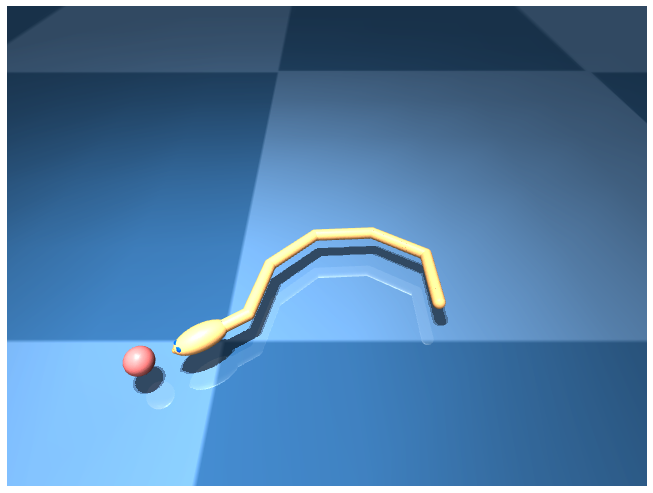

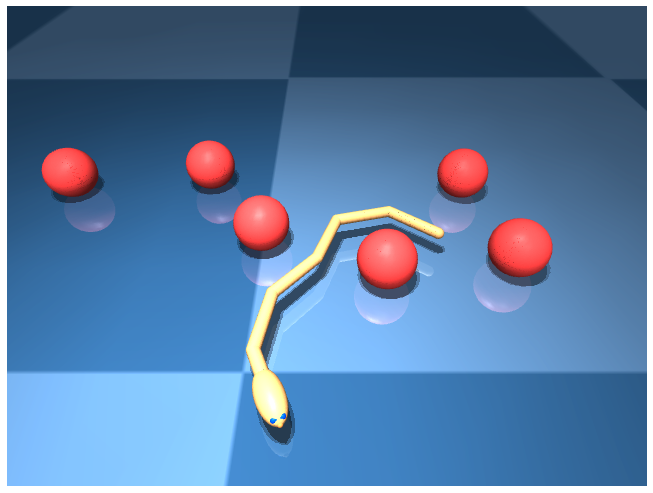

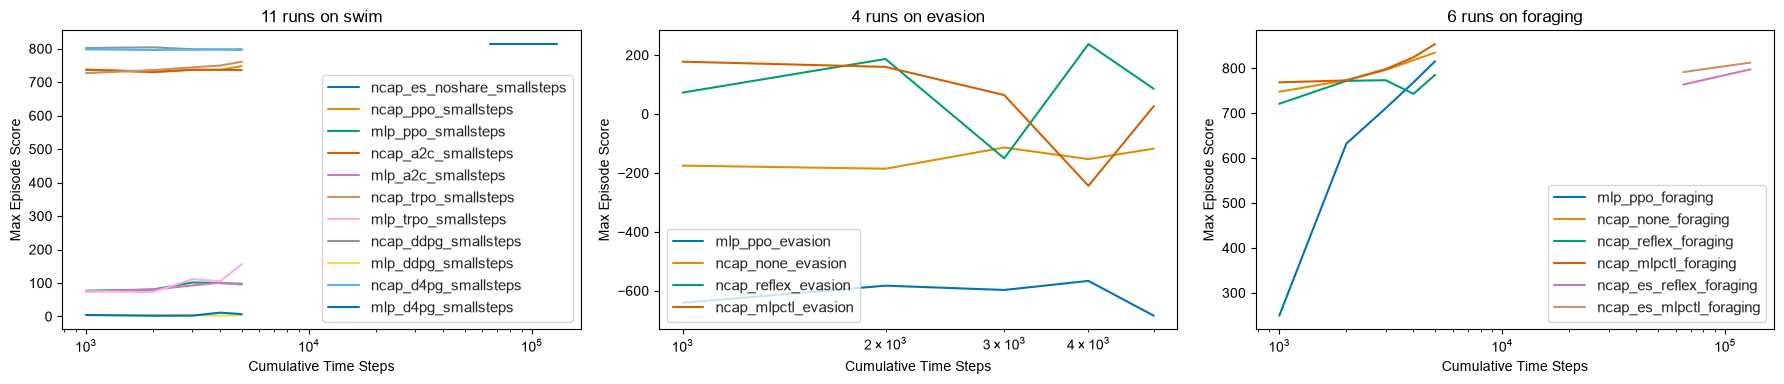

In [6]:
# rerun this cell if it displays more than the graphs
%matplotlib inline

# One panel per environment: the tasks reward different things (forward speed, food
# eaten, obstacles dodged), so their curves do not belong on shared axes.
tasks = list(dict.fromkeys(run['task'] for run in RUNS))
fig, axes = plt.subplots(1, len(tasks), figsize=(6 * len(tasks), 4), squeeze=False)

# Learning curve of every run trained above, from the same RUNS list, so the paths
# always match what the training cell wrote. plot_performance names each curve after
# the last folder of its path -- i.e. the run's label.
for ax, task in zip(axes[0], tasks):
    task_runs = [run for run in RUNS if run['task'] == task]
    # The legend names every curve, so only spell the runs out in the title while they
    # still fit on one line.
    if len(task_runs) <= 3:
        title = ' v/s '.join(run['label'].upper() for run in task_runs)
    else:
        title = f'{len(task_runs)} runs on {task}'
    plot_performance([run_path(**run) for run in task_runs], ax=ax, title=title)

plt.tight_layout()
plt.show()

In [7]:
# Replay the last checkpoint of every run and render it as video. To watch a single
# run instead, call play_model on just its path, e.g. play_model(run_path(**RUNS[0])).
#
# An ES checkpoint is a bare policy state_dict rather than a tonic agent, so tonic's
# player cannot load it; play_es_model rebuilds the policy and replays the best one.


# be careful here: this function reads from labels, so if you have multiple runs with the same label,
#  it will only play one. Make sure to give each run a unique label if you want to play them all.
print(f'\n=== {run["label"]} ===')
play = play_es_model if run['method'] == 'es' else play_model
display(play(run_path(**run)))


=== ncap_es_mlpctl_foraging ===
Loaded data/local/experiments/es/swimmer-foraging/ncap_es_mlpctl_foraging\checkpoints\best.pt -- episode score 816.43
